(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

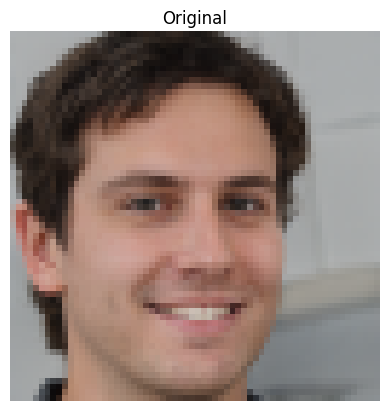

In [1]:
import cv2
import matplotlib.pyplot as plt

img_path = "data/processed_64/face-1.png"  # change this
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original")
plt.axis("off")

In [2]:
from src.data.transforms import get_train_transform

transform = get_train_transform(64)

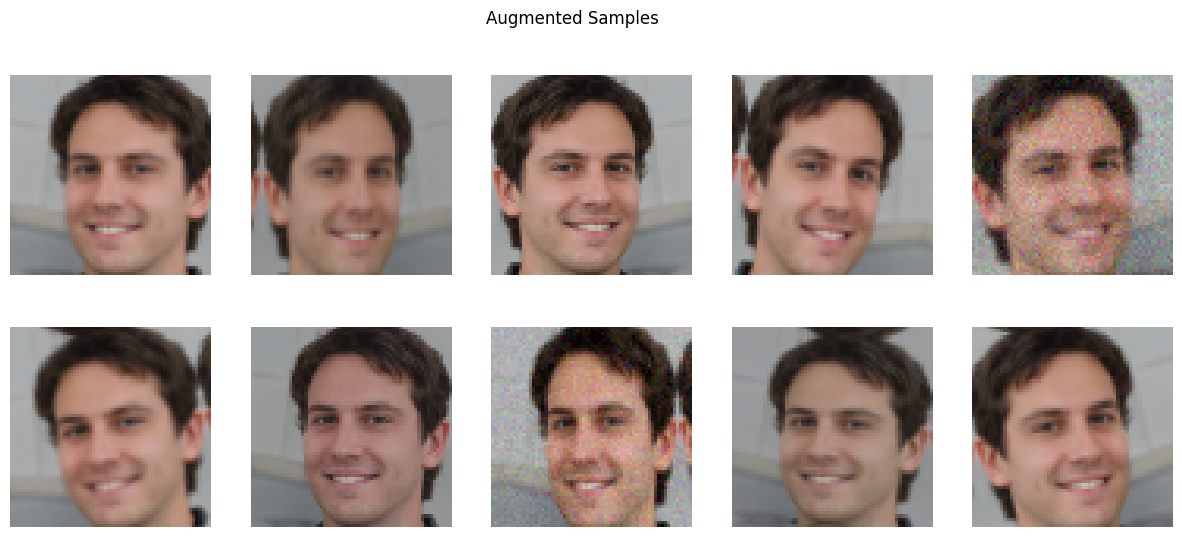

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    augmented = transform(image=img)["image"]
    
    # Convert tensor → numpy for display
    aug_img = augmented.permute(1, 2, 0).cpu().numpy()
    
    ax.imshow(aug_img)
    ax.axis("off")

plt.suptitle("Augmented Samples")
plt.show()

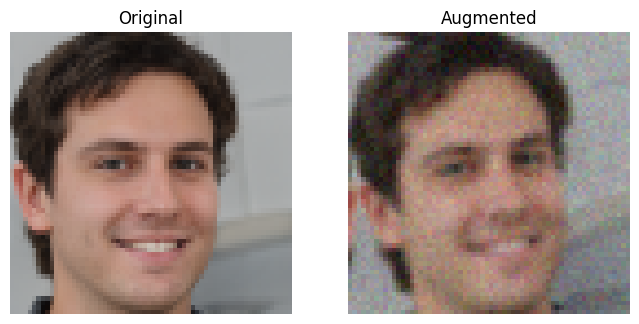

In [4]:
augmented = transform(image=img)["image"]
aug_img = augmented.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(aug_img)
ax[1].set_title("Augmented")
ax[1].axis("off")

plt.show()

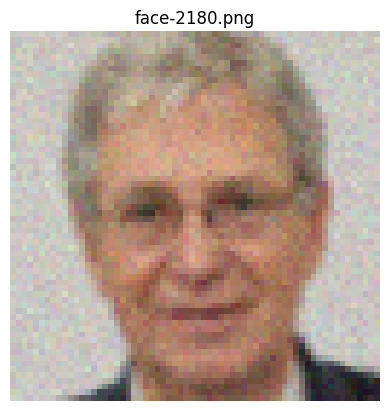

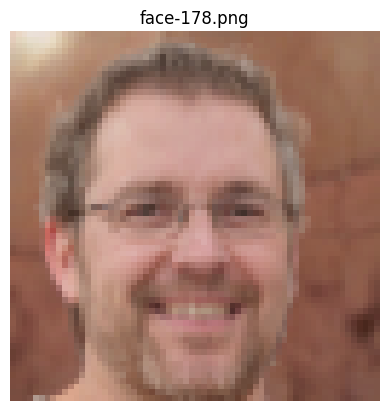

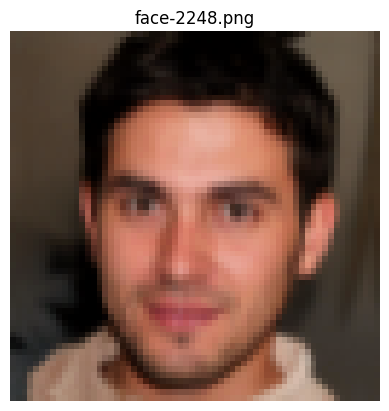

In [5]:
import os
import random

files = os.listdir("data/processed_64")

for file in random.sample(files, 3):
    img = cv2.imread(os.path.join("data/processed_64", file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    augmented = transform(image=img)["image"]
    aug_img = augmented.permute(1, 2, 0).cpu().numpy()

    plt.imshow(aug_img)
    plt.title(file)
    plt.axis("off")
    plt.show()